In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch

In [2]:
loaded = torch.load("../dummy_frame.pt")

images = [loaded['image']]
targets = [loaded['targets']]

In [3]:
targets[0].keys()

dict_keys(['boxes', 'labels', 'masks', 'energy_maps', 'energy_masks', 'vmap', 'vmask', 'distances', 'instance_ids'])

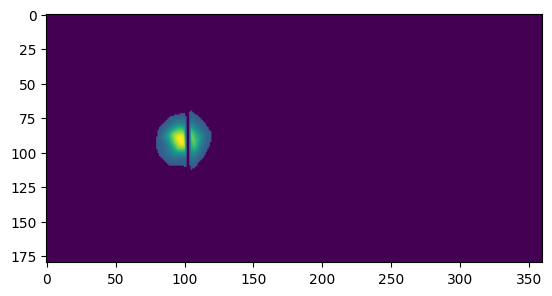

In [4]:
plt.imshow(targets[0]['energy_maps'][0])

In [5]:
import sys
import os

# 1. Calculate the path to the directory outside your current folder
# (Example: going up one level to a folder named 'external_folder')
cwd = os.getcwd()
target_dir = os.path.abspath(os.path.join(cwd, '..'))

# 2. Add that directory to Python's search path
sys.path.append(target_dir)

# 3. Import your class normally
from models.model import UNetSAISELD

sys.path.append(cwd)


In [6]:
def load_model(checkpoint_path: str, num_classes: int=None) -> UNetSAISELD:
    if not os.path.isfile(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
    print(f"[INFO] Loading checkpoint: {checkpoint_path}")

    model = UNetSAISELD(
        n_classes = 14,
        in_ch     = 4,
        img_h     = 180,
        img_w     = 360,
    )
    state = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
    if isinstance(state, dict):
        if   "model_state"      in state: state = state["model_state"]
        elif "model_state_dict" in state: state = state["model_state_dict"]

    missing, unexpected = model.load_state_dict(state, strict=True)
    if missing:    print(f"[WARN] Missing keys    : {missing}")
    if unexpected: print(f"[WARN] Unexpected keys : {unexpected}")

    model.to('cpu')
    model.eval()
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"[INFO] UNetSAISELD ready — {n_params:.1f}M params, eval() mode.")
    return model

In [7]:
model = load_model('/teamspace/studios/this_studio/New_Model/experiments/debug_with_gaussian_20260603_134156/unet_saiseld_best.pth')

[INFO] Loading checkpoint: /teamspace/studios/this_studio/New_Model/experiments/debug_with_gaussian_20260603_134156/unet_saiseld_best.pth
[INFO] UNetSAISELD ready — 104.4M params, eval() mode.


In [37]:
pred = model(images)

In [31]:
vmap = targets[0]['energy_maps'][0]
y, x = torch.where(vmap == vmap.max())
print(y[0]/180, x[0]/360)

tensor(0.4944) tensor(0.2694)


In [38]:
pred[0]

tensor([0.5111, 0.6142], grad_fn=<SelectBackward0>)

In [39]:
pred = pred.detach().numpy()

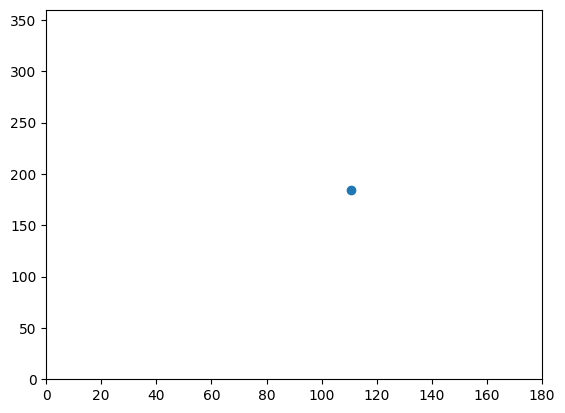

In [32]:

plt.scatter([pred[0][1]*180], [pred[0][0]*360])
plt.ylim(0, 360)
plt.xlim(0, 180)
plt.show()

In [37]:

def _get(keys):
                    for k in keys:
                        if k in pred[0]:
                            v = pred[0][k]
                            return v.cpu().numpy() if isinstance(v, torch.Tensor) else v
                    return None

labels_np = _get(["labels", "pred_classes", "pred_labels"])
scores_np = _get(["scores", "pred_scores",  "confidences"])
boxes_np  = _get(["boxes",  "pred_boxes",   "bboxes"])
emaps_np  = _get(["energy_maps", "energy",  "heatmaps"])

In [ ]:
emaps_np.shape